In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [223]:
df = pd.read_csv("/content/IMDB Dataset.csv")

In [224]:
df.to_csv("cleaned IMDB_Dataset.csv", index=False)
print("dataset saved successfully!")

dataset saved successfully!


In [225]:
from google.colab import files
files.download("cleaned IMDB_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [226]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (50000, 2)


In [227]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [228]:
df.shape

(50000, 2)

In [229]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [230]:
df.isnull().sum()

,0
review,0
sentiment,0


In [231]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


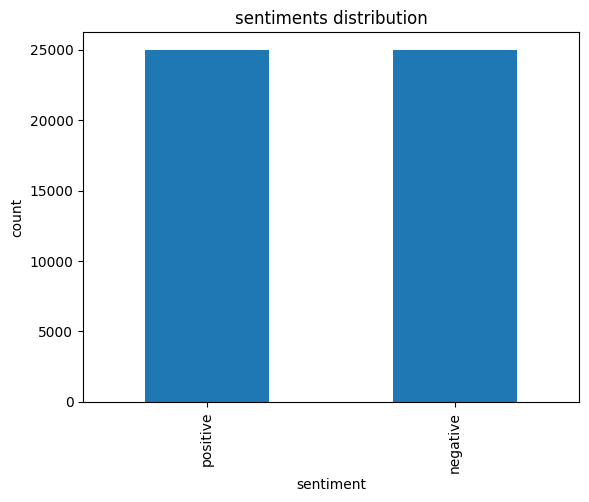

In [232]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("sentiments distribution")
plt.xlabel("sentiment")
plt.ylabel("count")
plt.show()

In [233]:
df['review']= df['review'].str.lower()

In [234]:
df['review'][3]

"basically there's a family where a little boy (jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />this movie is slower than a soap opera... and suddenly, jake decides to become rambo and kill the zombie.<br /><br />ok, first of all when you're going to make a film you must decide if its a thriller or a drama! as a drama the movie is watchable. parents are divorcing & arguing like in real life. and then we have jake with his closet which totally ruins all the film! i expected to see a boogeyman similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. as for the shots with jake: just ignore them."

In [235]:
import re
def clean_text(text):
  text = re.sub(r'[^a-zA-Z\s]','',text)
  return text
df['review']=df['review'].apply(clean_text)

In [236]:
df['review'][3]

'basically theres a family where a little boy jake thinks theres a zombie in his closet  his parents are fighting all the timebr br this movie is slower than a soap opera and suddenly jake decides to become rambo and kill the zombiebr br ok first of all when youre going to make a film you must decide if its a thriller or a drama as a drama the movie is watchable parents are divorcing  arguing like in real life and then we have jake with his closet which totally ruins all the film i expected to see a boogeyman similar movie and instead i watched a drama with some meaningless thriller spotsbr br  out of  just for the well playing parents  descent dialogs as for the shots with jake just ignore them'

In [237]:
import re
def clean(text):
  text=re.sub(r'<.*?>','',text)
  text=text.lower()
  text=re.sub(r'[^a-zA-Z\s]','',text)
  text = re.sub(r'\bbr\b', '', text)
  return text

df['review']=df['review'].apply(clean)

In [238]:
df['review'][25000]

'this movie was bad from the start the only purpose of the movie was that angela wanted to get a high body count the acting was horrible the killings were acted out very badly like when ally got stuffed down that toilet i guess it was in the abandoned cabin but when the end of the movie comes and molly and the other guy are in the cabin you see ally so angela must have gone in to get her the part that really got me was when the black girl and angela were in the cabin and angela took the guitar string and chocked her one it was horrible acting and two why wouldnt you just turn around and punch the bitch then when molly is getting chased by angela if you have the neigh why not just turn around and stab her so stupid this movie sucked'

In [239]:
df.shape

(50000, 2)

In [240]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [241]:
stop_words= set(stopwords.words('english'))

In [242]:
print(stop_words)

{'between', 'him', 'mustn', 'm', 'during', 'myself', 'more', 'under', 'yourself', 'doing', "didn't", 'which', 'i', 'those', 'ours', 'shouldn', 'mightn', 'so', 'd', 've', 'been', 'or', 'just', 'before', "he'd", "mightn't", 'will', "shan't", 'until', 'and', 'here', 'needn', "that'll", 'about', 'yours', 'why', 'this', 'them', 'his', 'the', 'through', 'shan', 'having', 'was', 'with', 'we', 'its', 'does', 'wouldn', "doesn't", "wouldn't", 'if', 'then', "i'd", 'nor', 'hasn', "they're", 'her', 'that', 'she', "wasn't", 'against', 'isn', 'but', 'doesn', 'itself', 'further', 're', 'were', 'where', 'won', 'our', 'both', 'should', 'after', "he's", "it's", 'an', 'out', 'in', 'while', "they'll", "needn't", 'only', "we'd", 'hers', 'off', 'all', 'to', 'few', 'it', "don't", 'didn', 'ma', 's', 'what', 'on', "we'll", "you'll", 'me', 'couldn', 'do', 'have', 'from', "she'd", 'these', 'once', 'can', 'whom', 'themselves', 'up', 'your', 'above', 'by', "mustn't", 'over', "they've", 'as', 'a', 'any', 'at', 'don'

In [243]:
def remove(text):
  words=text.split()
  filtered=[word for word in words if word not in stop_words]
  return " ".join(filtered)


In [244]:
df['review'] = df['review'].apply(remove)

In [245]:
df

,review,sentiment
0,one reviewers mentioned watching oz episode yo...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive
...,...,...
49995,thought movie right good job wasnt creative or...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary schools n...,negative
49998,im going disagree previous comment side maltin...,negative


In [246]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [247]:
from nltk.tokenize import word_tokenize

In [248]:
tokens = word_tokenize(df['review'][0])
print(tokens)

['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'mebr', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordbr', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cells', 'glass', 'fronts', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'manyaryans', 'muslims', 'gangstas', 'latinos', 'christians', 'italians', 'irish', 'moreso', 'scuffles', 'death', 'stares', 'dodgy', 'dealings', 'shady', 'agreements', 'never', 'far', 'awaybr', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goes', 'shows', 'wouldnt', 'dare', 'forget', 'pretty', 'pictures', 'painted', 'mainstream'

In [249]:
df['review'][0]

'one reviewers mentioned watching oz episode youll hooked right exactly happened mebr first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordbr called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awaybr would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle cl

In [250]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [251]:
def stem_text(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

In [219]:
df['review'] = df['review'].apply(stem_text)

In [220]:
df['review'][0]

'one review mention watch oz episod youll hook right exactli happen mebr first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordbr call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home manyaryan muslim gangsta latino christian italian irish moreso scuffl death stare dodgi deal shadi agreement never far awaybr would say main appeal show due fact goe show wouldnt dare forget pretti pictur paint mainstream audienc forget charm forget romanceoz doesnt mess around first episod ever saw struck nasti surreal couldnt say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard wholl sold nickel inmat wholl kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom co

In [221]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    df['sentiment'],
    test_size=0.2,
    random_state=0
)

ValueError: Found input variables with inconsistent numbers of samples: [49582, 50000]

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [252]:
model.fit(X_train, y_train)

LogisticRegression(C=20, max_iter=5000, random_state=42, solver='liblinear')

In [253]:
df['review']

,review
0,one reviewers mentioned watching oz episode yo...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically theres family little boy jake thinks...
4,petter matteis love time money visually stunni...
...,...
49995,thought movie right good job wasnt creative or...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,catholic taught parochial elementary schools n...
49998,im going disagree previous comment side maltin...


In [254]:
print(X.shape)

(49582, 596010)


In [255]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90,
    max_features=700000,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['review'])

In [256]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

In [257]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=20,
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(C=20, max_iter=5000, random_state=42, solver='liblinear')

In [258]:
y_pred = model.predict(X_test)

In [259]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 91.01


In [260]:
print(X_train.shape)
print(X_test.shape)

(40000, 590235)
(10000, 590235)


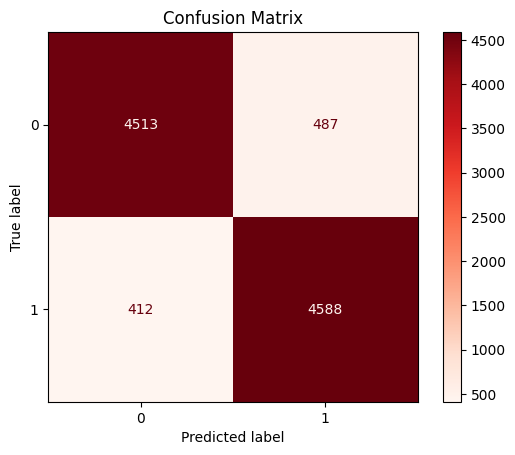

In [261]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Reds')
plt.title("Confusion Matrix")
plt.show()

In [262]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.92      0.90      0.91      5000
    positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [263]:
review = ["Bad Movie. A Waste of time."]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print(prediction)

['negative']


In [264]:
review = ["Good movie, Amazing acting"]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print(prediction)

['positive']


In [265]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [266]:
print(df.head())

                                              review sentiment
0  one reviewers mentioned watching oz episode yo...  positive
1  wonderful little production filming technique ...  positive
2  thought wonderful way spend time hot summer we...  positive
3  basically theres family little boy jake thinks...  negative
4  petter matteis love time money visually stunni...  positive
